<a href="https://colab.research.google.com/github/KateuleOrion/lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3: Neural Networks: Feedforward Networks and the Training Process

**Duration:** 1 week [21 Jul - 28 Jul, 2026]
**Due Date:** 28th July, 2026
**Format:** Jupyter Notebook / Google Colab
**Grading:** This is a graded lab.

**Student Name:** [Enter Name]
**Student ID:** [Enter ID]

---

### Objective

This lab bridges the gap between classical ML and deep learning. Instead of calling
`.fit()` and trusting scikit-learn, you will **open the black box**: build a neural network
from a single neuron upward, watch gradient descent learn, and then train a full
**feedforward network (MLP) in PyTorch** on a dataset you already know from Lab 2.

By the end you should be able to explain, and demonstrate with your own plots, what each
of these really does: **weights, activation functions, loss, gradients, learning rate,
epochs, batches, and overfitting**.

We deliberately stay on **tabular data** this week. Images and CNNs come in the next lab.

---
### Part 0: Repository Setup *(done outside this notebook)*

1. Create a **public** repository named `lab-3` on GitHub/GitLab.
2. Clone it locally (or link it to Google Colab).
3. Save this notebook inside the repo as `lab_3.ipynb`.
4. Add a `requirements.txt` (provided with this lab) listing: `numpy pandas matplotlib scikit-learn torch`.
5. Commit and push after completing **each Part** below — we will check your commit history.
   A single "final commit" with everything at once loses marks.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


---
# Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent

Before touching PyTorch's automation, you will build the moving parts **yourself with NumPy**
on a toy problem, so that nothing later in the lab is magic.

The toy problem: learn the function `y = sin(x)` on the interval `[-3, 3]` from 100 noisy
samples. It is 1-dimensional, so we can *plot everything* — the data, the model's prediction,
and the loss going down.

### Part 1.1 — A single neuron is just a line
A neuron computes `y_hat = w * x + b`. Fit it to the sine data with **manual gradient descent**.

In [2]:
# TODO: Generate the toy data

np.random.seed(42)
x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, size=x.shape)
y = np.sin(x) + noise

w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.05
epochs = 200

losses = []


for step in range(epochs):
    # Forward Pass
    y_hat = w * x + b

    # Compute Loss (MSE)
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Compute Gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update Weights
    w -= lr * dw
    b -= lr * db

#   Plot it.

# TODO: Initialise w and b to small random values.

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

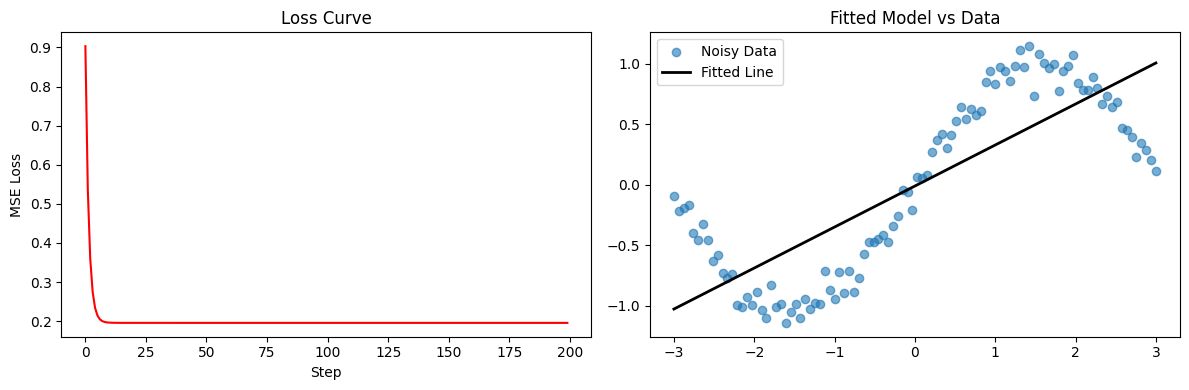

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, color='Red')
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")

axes[1].scatter(x, y, alpha=0.6, label="Noisy Data")
axes[1].plot(x, w * x + b, color='black', linewidth=2, label="Fitted Line")
axes[1].set_title("Fitted Model vs Data")
axes[1].legend()

plt.tight_layout()
plt.show()

**Student Reasoning — The single neuron**
*1. Derive `dLoss/dw` on paper and include a photo or the LaTeX in this cell — does it match
the code?* 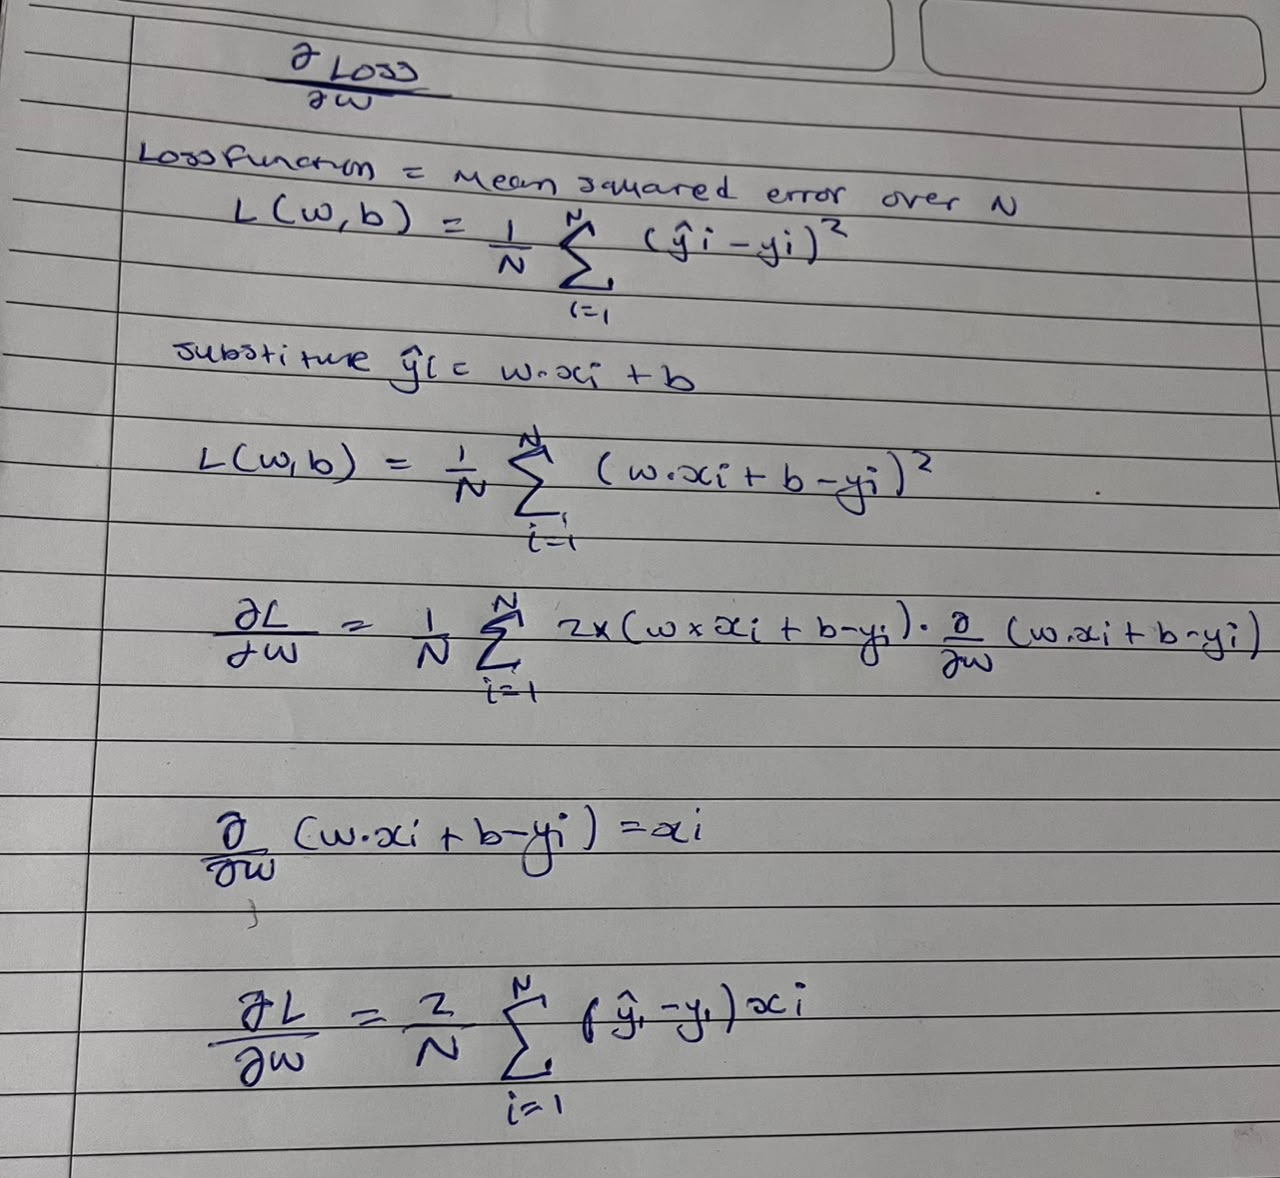

My derivation matches the code formular: dw = np.mean(2 * (y_hat - y) * x).
*2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting,
and WHY can a single neuron never fit a sine wave, no matter how long you train?*

**Answer**

This is underfitting because a single neuron computes linear combinations that represent a straight line. This causes it to lack the hypothesis capability to curve regardless of how long the training is since a Sine wave is a non-linear function.


### Part 1.2 — Hidden layers and activations: why depth helps
Now build a tiny network **by hand**: 1 input -> a hidden layer of 8 neurons with `tanh` ->
1 output. Still NumPy, still manual gradients.

In [4]:
np.random.seed(42)

X_mat = x.reshape(-1, 1)
Y_mat = y.reshape(-1, 1)

# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros((1, 1))

lr = 0.01
steps = 3000
losses_tanh = []

for step in range(steps):
    # Forward pass
    z1 = X_mat @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

    loss = np.mean((y_hat - Y_mat) ** 2)
    losses_tanh.append(loss)

    # Backward pass
    d_yhat = 2 * (y_hat - Y_mat) / len(Y_mat)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0, keepdims=True)

    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = X_mat.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    # Update parameters
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

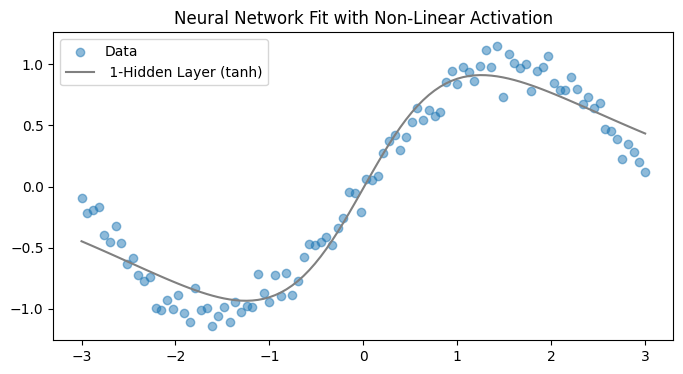

In [5]:
plt.figure(figsize=(8, 4))
plt.scatter(x, y, alpha=0.5, label="Data")
plt.plot(x, y_hat, color='grey', label=" 1-Hidden Layer (tanh)")
plt.title("Neural Network Fit with Non-Linear Activation")
plt.legend()
plt.show()

**Student Reasoning — Depth and activations**
*1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1.
Explain mathematically why a stack of linear layers collapses into one linear layer.*
*2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few
columns of `h` against `x`.)*
*3. This is exactly what `loss.backward()` will automate in Section 2. In one sentence, what
is backpropagation?*

> **Answer:**
1. Without Tahn, the linear layer representation becomes linearly represented as  h = z1 = X W1 + b1 And once sbstituted in the output layer's function, y^ = hW2 + b2 = (XW1 + b1) W2 + b2 = X(W1W_2) + (b1 W2 + b2)
Matrix multiplication of linear combinations is linear. Thus, a stacked deep neural network without non-linear activations collapses into a single linear mode.

2. A single neuron can only make a straight line. Each of the 8 hidden neurons compute an activation and creates it's own curve using tahn. The output layer then scales and adds these 8 different curves together to build the smooth wave shape of sin(x)

3. Backpropagation is using calculus chain rule to work backward through a network, calculating how much each weight contributed to the loss in order to know how to adjust them.

### Part 1.3 — The learning rate: too cold, too hot, just right
The single most important hyperparameter. See its three regimes with your own eyes.

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2024/69847128.py:23: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - Y_mat) ** 2)
/tmp/ipykernel_2024/69847128.py:30: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_2024/69847128.py:31: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


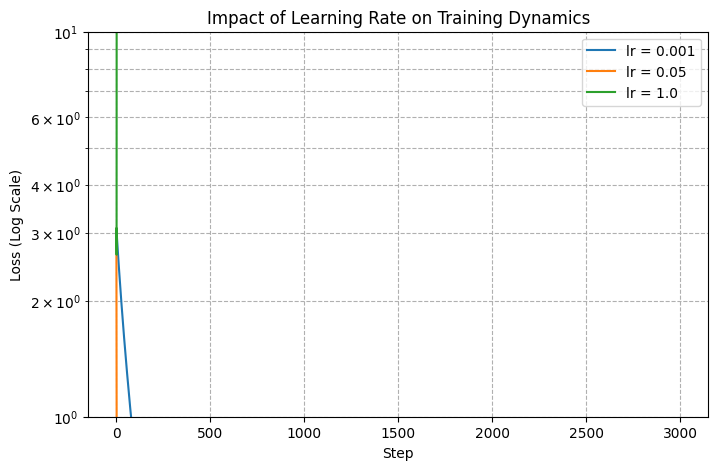

In [6]:

# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps=3000):
    # Reset seed for consistent initial weights
    np.random.seed(42)
    X_mat = x.reshape(-1, 1)
    Y_mat = y.reshape(-1, 1)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros((1, 8))
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros((1, 1))

    history = []


    for _ in range(steps):
        # Forward
        z1 = X_mat @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - Y_mat) ** 2)
        history.append(loss)

        # Backward
        d_yhat = 2 * (y_hat - Y_mat) / len(Y_mat)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0, keepdims=True)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = X_mat.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        # Update
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return history

# Run experiments across three learning rates
lrs = [0.001, 0.05, 1.0]
plt.figure(figsize=(8, 5))

for learning_rate in lrs:
    loss_hist = train_toy(learning_rate)
    plt.plot(loss_hist, label=f"lr = {learning_rate}")

plt.yscale('log')
plt.xlabel("Step")
plt.ylabel("Loss (Log Scale)")
plt.title("Impact of Learning Rate on Training Dynamics")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

**Student Reasoning — Learning rate**
*Describe what each of the three curves shows. Why does a too-large learning rate make the
loss explode or oscillate instead of just "learning faster"?*

> **Answer:**

Too Small (lr = 0.001): The loss goes down, but exceedingly slowly. It takes way too many steps to learn anything useful because the updates are tiny cautious baby steps.
Just right (lr = 0.05): The loss drops smoothly and quickly to a low number. The model learns efficiently without overshooting.

Too Large (lr = 1.0): The loss bounces around wildly or explodes (gets worse). Instead of settling down at a good fit, the updates jump back and forth erratically.

Why a too-large learning rate makes the loss explode instead of learning faster:
When the learning rate is too large, the weight update steps overshoot the minimum of the loss surface instead of stepping gently toward it. The gradient tells the model the direction, so an overly large step causes the updates to jump completely to an even higher, steeper point on the opposite side. With each subsequent step, the model bounces back and forth with growing errors, causing the loss to oscillate erratically or explode to infinity instead of converging.

---
# Section 2 — A Real Feedforward Network in PyTorch

Now we let PyTorch do the bookkeeping (`autograd`, optimizers, batching) and apply the ideas
from Section 1 to a real problem — one you already know:

## Predicting obesity level (`NObeyesdad`) — the Lab 2 dataset

Same data, same 7 classes, same preprocessing ideas — but this time the model is a neural
network you design and train yourself. At the end you will compare it head-to-head with your
Lab 2 classical models.

### Part 2.1 — Preprocess and split (recycled from Lab 2)
Reuse your Lab 2 pipeline: encode categoricals, scale numerics, stratified three-way split.

In [7]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

OBESITY_URL = "https://archive.ics.uci.edu/static/public/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition.zip"
df = pd.read_csv(OBESITY_URL)
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

binary_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] == 'yes').astype(int) if col != 'Gender' else (df[col] == 'Male').astype(int)

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

cat_cols = ['CAEC', 'CALC', 'MTRANS']
df = pd.get_dummies(df, columns=[c for c in cat_cols if c in df.columns], drop_first=True)

le = LabelEncoder()
X = df.drop(columns=['NObeyesdad']).values
y = le.fit_transform(df['NObeyesdad'])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
val_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"Data shapes -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

Data shapes -> Train: (1266, 23), Val: (422, 23), Test: (423, 23)


**Student Reasoning — Preprocessing for neural networks**
*1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in
PyTorch?*
*2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care
so much? Connect your answer to the gradient formulas you wrote in Section 1.*
*3. What does `shuffle=True` on the training DataLoader do, and why does it help?*

> **Answer:**

1. One-hot vectors are full of zeros, which wastes memory and forces the computer to do useless multiplications. PyTorch takes simple class numbers so it can instantly look up the correct target class and compute the loss faster using less memory.

2. If one feature is huge for example 10000 and another is tiny, the updates get unbalanced, making training unstable. Random Forests don't care about scaling because they just make simple Yes/No split decisions on one feature at a time, where the scale doesn't change the order of numbers.

3.It shuffles the training data into a new random order at the start of every epoch. This stops the model from accidentally memorizing the order of the dataset and ensures every mini-batch gives an unbiased gradient update.

### Part 2.2 — Design the network
An MLP: input -> hidden layers with ReLU -> 7 output logits.

In [15]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

import torch
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super(FeedForwardNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(hidden_sizes[1], n_classes)

    # Make sure this is lowercase "forward" and indented inside the class!
    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.out(x)
        return x




# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
input_dim = X_train.shape[1]  # Automatically get the number of features
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)

print("Model Architecture")
print(model)

# 3. Count Trainable Parameters using PyTorch
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters (PyTorch): {total_params}")

# 4. Verify First Layer Count By Hand: input_dim * 64 + 64
first_layer_hand_count = input_dim * 64 + 64
print(f"First Layer Parameter Count (By Hand): {first_layer_hand_count}")


# TODO: Instantiate, move to DEVICE, print the model.

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.

Model Architecture
FeedForwardNet(
  (fc1): Linear(in_features=23, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)

Total Trainable Parameters (PyTorch): 3847
First Layer Parameter Count (By Hand): 1536


**Student Reasoning — Architecture**
*1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.*
*2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.*
*3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.)*

> **Answer:**

1.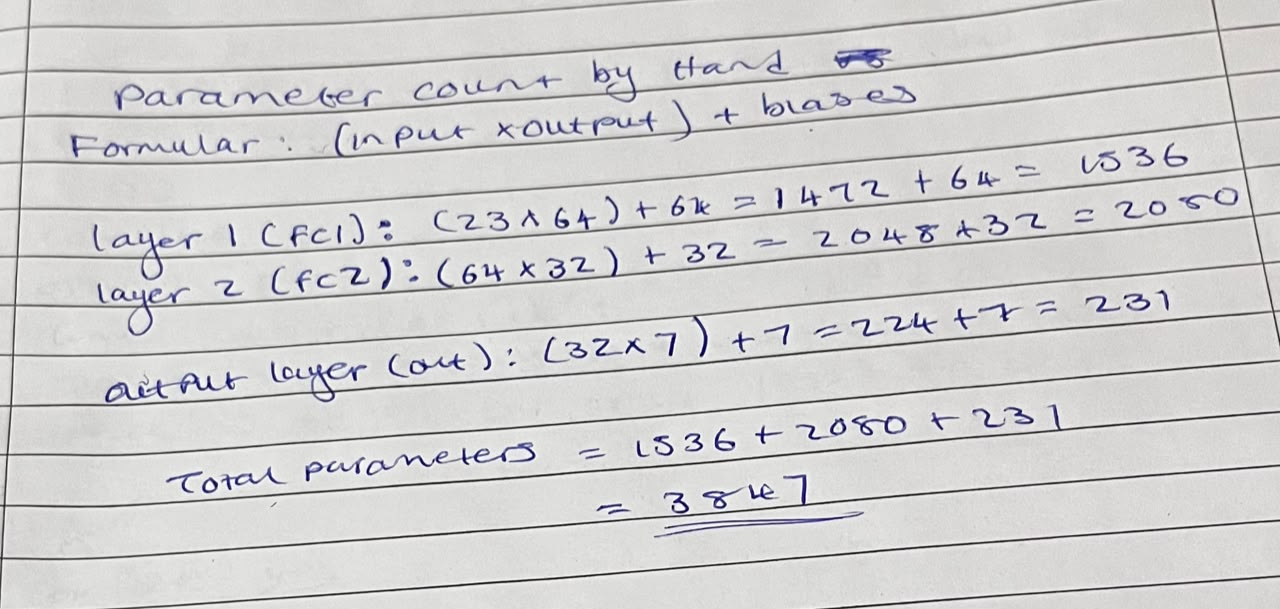
2. tanh reduces large inputs into flat regions near -1 or 1 where the gradient drops to nearly zero, slowing down training while ReLU keeps a constant gradient of 1 for all positive values, allowing signals to flow easily through the network.
ADVANTAGE: ReLU prevents the vanishing gradient problem and trains the dataset faster.
3. Without the activation function, the entire network yields just another linear equation, losing all ability to learn complex, non-linear shapes.

### Part 2.3 — The training loop
The same loop you built by hand in Section 1 — now with autograd, an optimizer, and batches.

In [16]:

import torch
import torch.nn as nn

# 1. Define Loss Function, Optimizer, Device, and Random Seed
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate the network
model = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=(64, 32), n_classes=7).to(DEVICE)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Tracking history
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
EPOCHS = 100

# 2. Full Training Loop
for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # Zero gradients, Forward pass, Backward pass, Optimize
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation Phase ---
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Save metrics
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

Epoch 010 | Train Loss: 0.4332, Acc: 0.8641 | Val Loss: 0.5665, Acc: 0.8223
Epoch 020 | Train Loss: 0.1641, Acc: 0.9605 | Val Loss: 0.4273, Acc: 0.8886
Epoch 030 | Train Loss: 0.0781, Acc: 0.9874 | Val Loss: 0.4296, Acc: 0.8957
Epoch 040 | Train Loss: 0.0404, Acc: 0.9968 | Val Loss: 0.4671, Acc: 0.9028
Epoch 050 | Train Loss: 0.0230, Acc: 1.0000 | Val Loss: 0.4929, Acc: 0.9076
Epoch 060 | Train Loss: 0.0140, Acc: 1.0000 | Val Loss: 0.5453, Acc: 0.9100
Epoch 070 | Train Loss: 0.0089, Acc: 1.0000 | Val Loss: 0.5766, Acc: 0.9100
Epoch 080 | Train Loss: 0.0057, Acc: 1.0000 | Val Loss: 0.6193, Acc: 0.9100
Epoch 090 | Train Loss: 0.0038, Acc: 1.0000 | Val Loss: 0.6402, Acc: 0.9076
Epoch 100 | Train Loss: 0.0028, Acc: 1.0000 | Val Loss: 0.6704, Acc: 0.9076


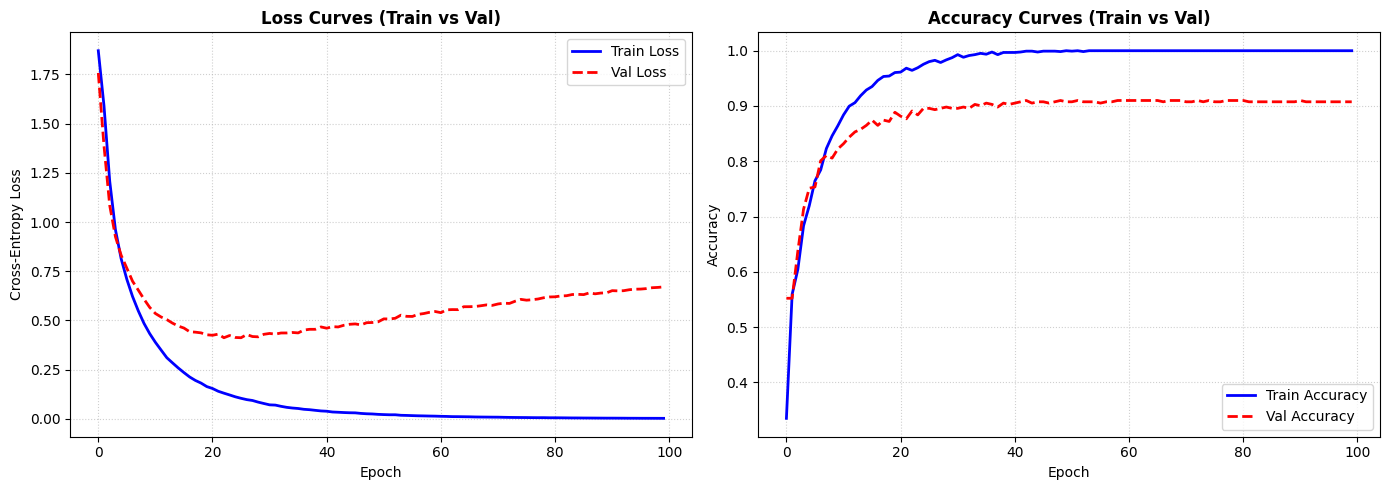

In [17]:
import matplotlib.pyplot as plt

# Set up a figure with 2 subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Loss Curves ---
ax1.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', color='red', linestyle='--', linewidth=2)
ax1.set_title('Loss Curves (Train vs Val)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=10)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=10)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# --- Plot 2: Accuracy Curves ---
ax2.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
ax2.plot(history['val_acc'], label='Val Accuracy', color='red', linestyle='--', linewidth=2)
ax2.set_title('Accuracy Curves (Train vs Val)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=10)
ax2.set_ylabel('Accuracy', fontsize=10)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Student Reasoning — Training**
*1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is
the forward pass, which computes gradients, which is the update rule?*
*2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the
specific numbers that back up your claim.*
*3. Why do we call `optimizer.zero_grad()` every batch? What silently goes wrong without it?*

> **Answer:**

1.
i. Forward pass
PyTorch
outputs = model(inputs)

NumPy
 z1 = X_mat @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2

ii. computes gradient

PyTorch
loss.backward()

Numpy
 d_yhat = 2 * (y_hat - Y_mat) / len(Y_mat)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0, keepdims=True)


iii. update rule

PyTorch
optimizer.step()

Numpy
  W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2


2. The model is overfitting

 The model achieves a nearly perfect training accuracy and a training loss that drops to almost 0, but its validation performance diverges wih 91% accuracy while the validation loss reaches a low of 0.42 before steadily creeping upward to 0.67 by epoch 100. This widening gap, is a sign of overfitting conveying that the neural network has begun memorizing the specific details and noise of the training dataset.

 3. Calling optimizer.zero_grad() clears all stored gradients from the previous mini-batch so that the model can compute new, independent gradients for the current batch.

### Part 2.4 — Experiments: how training choices change the outcome
Run **three controlled experiments**. Change ONE thing at a time; keep everything else fixed.

In [18]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Extended model class supporting dynamic layer sizes and dropout
class ExperimentNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super(ExperimentNet, self).__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_sizes:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
    # Set seed for reproducibility
    torch.manual_seed(RANDOM_STATE)

    # Prepare DataLoaders
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
    val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))

    exp_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    exp_val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize Model, Criterion, Optimizer
    input_dim = X_train.shape[1]
    model = ExperimentNet(input_dim, hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in exp_train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation Phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in exp_val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    return history

Running Experiment A...


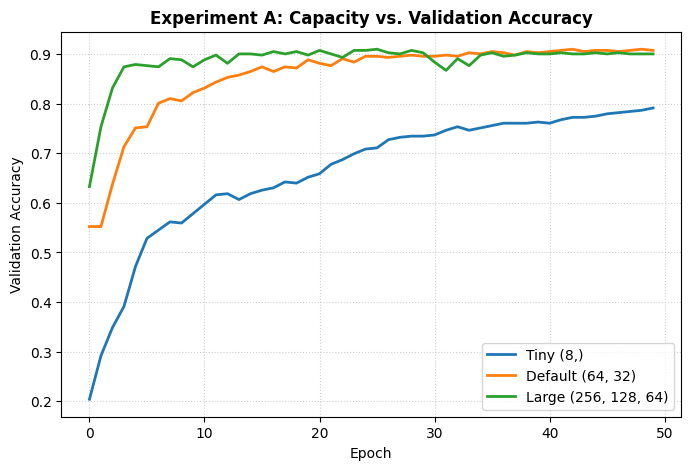

In [19]:
import matplotlib.pyplot as plt
# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.


print("Running Experiment A...")
hist_tiny = run_experiment(hidden_sizes=(8,), epochs=50)
hist_default = run_experiment(hidden_sizes=(64, 32), epochs=50)
hist_large = run_experiment(hidden_sizes=(256, 128, 64), epochs=50)

# Plotting Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(hist_tiny['val_acc'], label='Tiny (8,)', linewidth=2)
plt.plot(hist_default['val_acc'], label='Default (64, 32)', linewidth=2)
plt.plot(hist_large['val_acc'], label='Large (256, 128, 64)', linewidth=2)
plt.title('Experiment A: Capacity vs. Validation Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Running Experiment B...


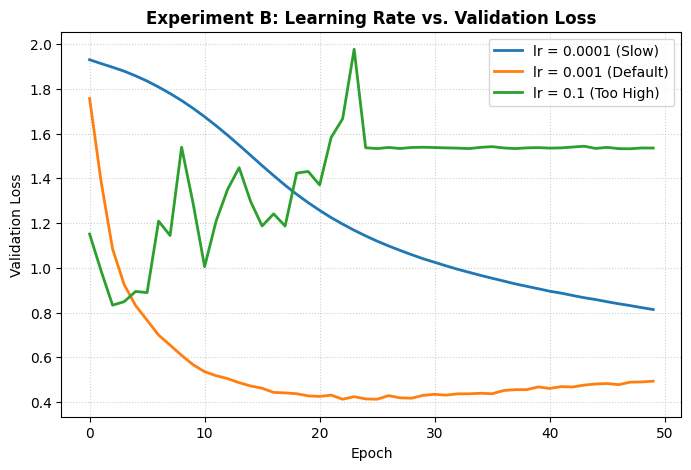

In [20]:
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.


print("Running Experiment B...")
hist_lr_low = run_experiment(lr=1e-4, epochs=50)
hist_lr_mid = run_experiment(lr=1e-3, epochs=50)
hist_lr_high = run_experiment(lr=1e-1, epochs=50)

# Plotting Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(hist_lr_low['val_loss'], label='lr = 0.0001 (Slow)', linewidth=2)
plt.plot(hist_lr_mid['val_loss'], label='lr = 0.001 (Default)', linewidth=2)
plt.plot(hist_lr_high['val_loss'], label='lr = 0.1 (Too High)', linewidth=2)
plt.title('Experiment B: Learning Rate vs. Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Running Experiment C...


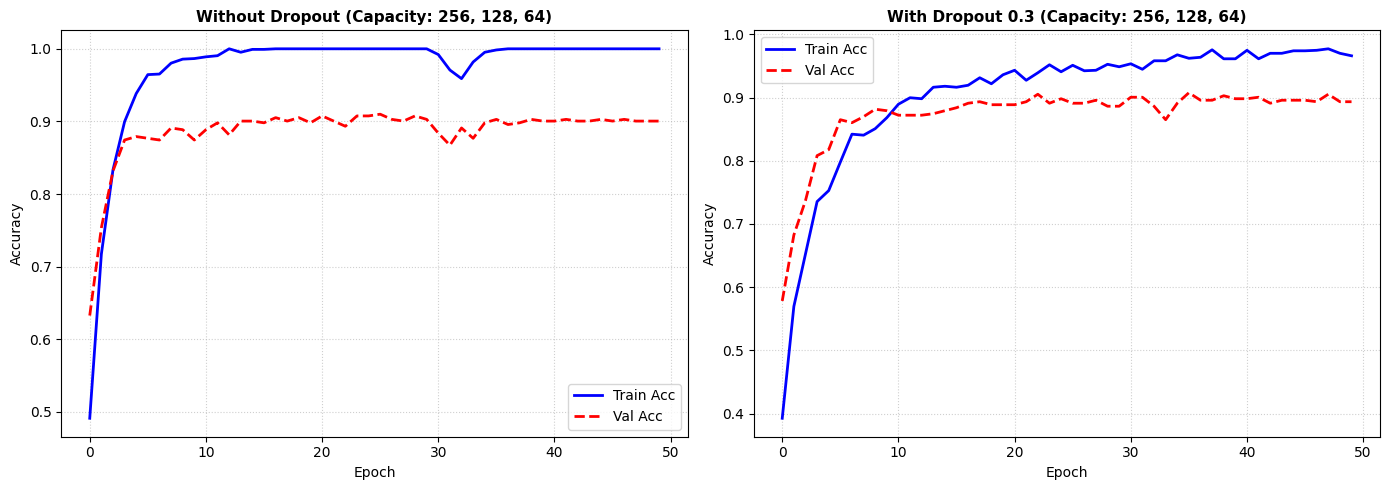

In [21]:
# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

print("Running Experiment C...")
hist_no_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0, epochs=50)
hist_with_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3, epochs=50)

# Plotting Train vs Val Accuracy for both runs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Without Dropout
ax1.plot(hist_no_dropout['train_acc'], label='Train Acc', color='blue', linewidth=2)
ax1.plot(hist_no_dropout['val_acc'], label='Val Acc', color='red', linestyle='--', linewidth=2)
ax1.set_title('Without Dropout (Capacity: 256, 128, 64)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot 2: With Dropout (0.3)
ax2.plot(hist_with_dropout['train_acc'], label='Train Acc', color='blue', linewidth=2)
ax2.plot(hist_with_dropout['val_acc'], label='Val Acc', color='red', linestyle='--', linewidth=2)
ax2.set_title('With Dropout 0.3 (Capacity: 256, 128, 64)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

**Student Reasoning — Experiments**
*1. Capacity: did the largest network win on validation data? Where do you see diminishing returns or overfitting?*
*2. Learning rate: do the three regimes match what you saw on the toy problem in Part 1.3?*
*3. Regularization: what did dropout do to the train-vs-validation gap? Explain in one or two sentences HOW dropout achieves this.*

> **Answer:**

1. No. While the Large (256, 128, 64) network converged fastest in early epochs, its final performance was around 90%, matching the Default (64, 32) network by Epoch 50.
Diminishing returns occur when moving from Default to Large, as adding thousands of parameters yields no higher final validation accuracy. Signs of overfitting appear in the Large model's noisy, fluctuating validation accuracy curve compared to Default's smoother, steadiness.

2. Yes they match.
Low(lr=lr=1e-4): Stable and smooth loss reduction, but converges far too slowly (underfitting at Epoch 50).
Moderate(lr= 1e-3 ):decreases loss rapidly and smoothly settles into a low minimum around 0.42.
High (lr= 1e-1): Unstable and chaotic—the loss oscillates wildly, spikes around Epoch 23, and stays stuck at a high validation loss (~1.54).

3. Impact on Gap: Dropout drastically reduced the generalization gap from 10% (100% train vs. 90% val) down to 7% (97% train vs. 90% val) by preventing training accuracy from hitting a memorized 100%.

How Dropout Achieves This: By randomly deactivating 30% of neurons during each training forward pass, dropout prevents neurons from co-adapting and relying on specific input features. This forces the network to learn redundant feature representations that generalize better to unseen validation data.

### Part 2.5 — Final evaluation and showdown with Lab 2
One honest number on the test set — then compare with your classical models.

In [11]:
# TODO: Load your best configuration's weights; model.eval().

# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay

# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]

**Student Reasoning — Final evaluation**
*1. Which obesity levels does the network still confuse, and are they the same ones your
Lab 2 classifier confused?*
*2. Who wins the showdown — the neural network or the classical model? Was the extra effort
of deep learning worth it on THIS dataset? When would it be?*

> **Answer:** [Double-click to edit]

---
# Section 3 — Reflection

*Answer in a few sentences each:*

1. **The black box, opened:** Name the three most important things happening inside
   `loss.backward()` and `optimizer.step()`, in your own words.
2. **Hyperparameters:** If you could tune only ONE hyperparameter on a new problem, which
   would you pick and why?
3. **Overfitting:** Across your experiments, where did you see the biggest
   train-vs-validation gap, and which intervention reduced it most?
4. **Looking ahead:** This network treats every input feature independently. Next lab we move
   to images, where nearby pixels are related. Why might a plain MLP struggle with images,
   and what property should a better architecture have?

> **Answer:** [Double-click to edit]

---
### Submission checklist

- [ ] All cells run top-to-bottom with no errors (`Kernel -> Restart & Run All`).
- [ ] Every **Student Reasoning** box is filled in with full sentences.
- [ ] Plots are visible in the saved notebook (loss curves, fits, experiments, confusion matrix).
- [ ] Notebook committed and pushed to your `lab-3-feedforward-networks` repository, with
      incremental commits (not one final dump).
- [ ] Repository link submitted to the course portal.
- [ ] AI Declaration form in Repository.